<a href="https://colab.research.google.com/github/Dhumarsio/Cluster-tambos/blob/main/Cluster_del_proyecto_final_teorico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install streamlit pyngrok -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 48.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 35.5 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from matplotlib.patches import Patch
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

plt.rcParams["figure.figsize"] = (12, 5)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving datostambo.csv to datostambo.csv


In [ ]:
df_fiero = pd.read_csv("datostambo.csv", sep=";", header=0)

categoricas = ["Provincia", "Localidad", "CUENCA LECHERA", "Sistema alimentación"]
for col in df_fiero.columns:
    if col not in categoricas:
        df_fiero[col] = pd.to_numeric(df_fiero[col], errors="coerce")

df_fiero = df_fiero.rename(columns={
    "ID. Productor:":                                "id",
    "CUENCA LECHERA":                                "cuenca",
    "Sistema alimentación":                          "sistema",
    "SUPERFICIE TOTAL TAMBO (Has)":                  "sup_total_ha",
    "VO":                                            "vo",
    "VS":                                            "vs",
    "VT":                                            "vt",
    "Carga VT":                                      "carga_vt",
    "Kg MS concentrado / VO / dia - promedio anual": "concentrado",
    "CMS":                                           "cms",
    "CMS pastura":                                   "cms_pastura",
    "lts":                                           "lts_dia",
    "%GB":                                           "pct_gb",
    "%PC":                                           "pct_pc",
    "LCG":                                           "lcg",
    "Terneras recría (< 12 meses)":                  "terneras_recria",
    "Total Tambo TNCO2eq / año":                     "total_tambo_tnco2",
    "Total establecimiento TNCO2eq / año":           "total_estab_tnco2",
    "Total leche KgCO2eq / Lt":                      "huella_kgco2_lt",
})

df_fiero["pct_gb"] = df_fiero["pct_gb"].replace(0, np.nan)
df = df_fiero.dropna(subset=["huella_kgco2_lt"]).copy()
# Eliminar tambo con dato erróneo
df = df[df["id"] != 102].copy()

TASA = 16
df["costo_ambiental_eur"] = df["total_estab_tnco2"] * TASA

print(f"Registros totales:              {len(df_fiero)}")
print(f"Registros con huella calculada: {len(df)}")

Registros totales:              125
Registros con huella calculada: 116


=== Estadísticas de huella_kgco2_lt ===
count    117.000
mean       0.762
std        0.203
min        0.500
25%        0.620
50%        0.690
75%        0.870
max        1.550
Name: huella_kgco2_lt, dtype: float64

Asimetría: 1.202


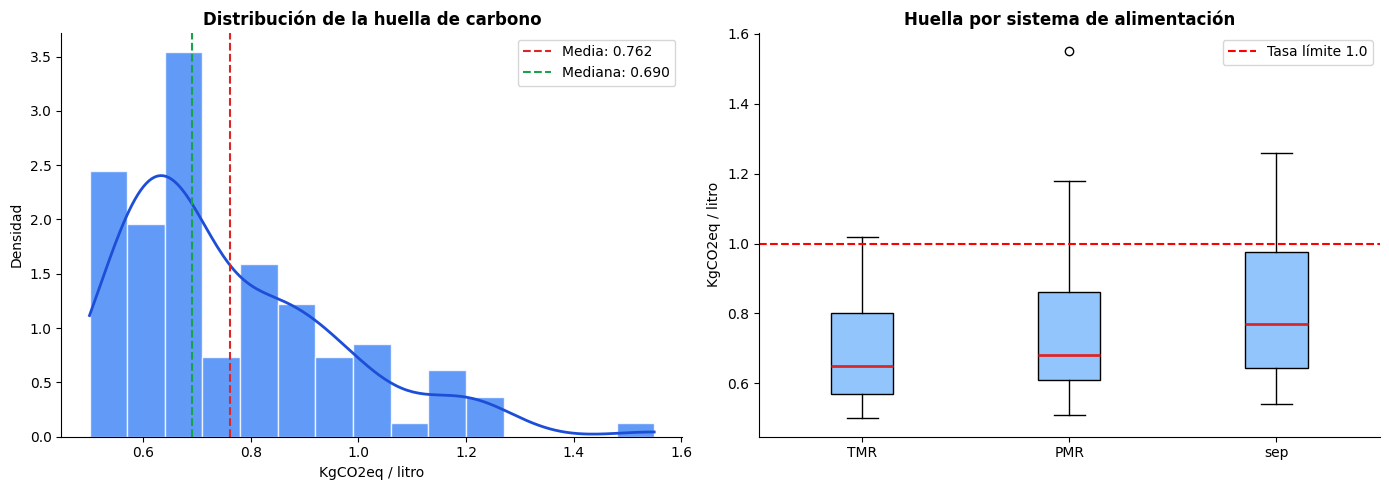

In [ ]:
print("=== Estadísticas de huella_kgco2_lt ===")
print(df["huella_kgco2_lt"].describe().round(3))
print(f"\nAsimetría: {df['huella_kgco2_lt'].skew():.3f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df["huella_kgco2_lt"], bins=15, color="#3b82f6",
             edgecolor="white", alpha=0.8, density=True)
kde_x = np.linspace(df["huella_kgco2_lt"].min(), df["huella_kgco2_lt"].max(), 200)
kde = stats.gaussian_kde(df["huella_kgco2_lt"].dropna())
axes[0].plot(kde_x, kde(kde_x), color="#1d4ed8", linewidth=2)
axes[0].axvline(df["huella_kgco2_lt"].mean(), color="#dc2626", linestyle="--",
                label=f"Media: {df['huella_kgco2_lt'].mean():.3f}")
axes[0].axvline(df["huella_kgco2_lt"].median(), color="#16a34a", linestyle="--",
                label=f"Mediana: {df['huella_kgco2_lt'].median():.3f}")
axes[0].set_title("Distribución de la huella de carbono", fontweight="bold")
axes[0].set_xlabel("KgCO2eq / litro")
axes[0].set_ylabel("Densidad")
axes[0].legend()

orden = df.groupby("sistema")["huella_kgco2_lt"].median().sort_values().index.tolist()
grupos = [df[df["sistema"] == s]["huella_kgco2_lt"].dropna() for s in orden]
axes[1].boxplot(grupos, tick_labels=orden, patch_artist=True,
                boxprops=dict(facecolor="#93c5fd"),
                medianprops=dict(color="#dc2626", linewidth=2))
axes[1].axhline(1.0, color="red", linestyle="--", label="Tasa límite 1.0")
axes[1].set_title("Huella por sistema de alimentación", fontweight="bold")
axes[1].set_ylabel("KgCO2eq / litro")
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
fuentes = {
    "Fermentación enterica tambo CH4 TNCO2eq / año": "pct_ferment_enteric",
    "Fermentacion entérica Recría TNCO2eq / año":    "pct_ferment_recria",
    "Animales CH4 TNCO2eq / año":                    "pct_animales_ch4",
    "Animales N2O TNCO2eq / año":                    "pct_animales_n2o",
    "Fertilizante N2O TNCO2eq / año":                "pct_fertilizante",
    "Fertilizante (propio) N2O TNCO2eq / año":       "pct_fertilizante_propio",
    "Energia CO2 TNCO2eq / año":                     "pct_energia",
    "Manejo Estiercol CH4 TNCO2eq / año":            "pct_manejo_estiercol",
    "Estiercol en pasturas N2O TNCO2eq / año":       "pct_estiercol_n2o",
}

for col_orig, col_nuevo in fuentes.items():
    df[col_nuevo] = df[col_orig] / df["total_estab_tnco2"]

cols_pct = list(fuentes.values())

print("Peso promedio por fuente:")
print(df[cols_pct].mean().sort_values(ascending=False).round(3))

Peso promedio por fuente:
pct_ferment_enteric        0.713
pct_animales_ch4           0.204
pct_ferment_recria         0.204
pct_animales_n2o           0.067
pct_fertilizante           0.049
pct_fertilizante_propio    0.033
pct_energia                0.032
pct_manejo_estiercol       0.030
pct_estiercol_n2o          0.020
dtype: float64


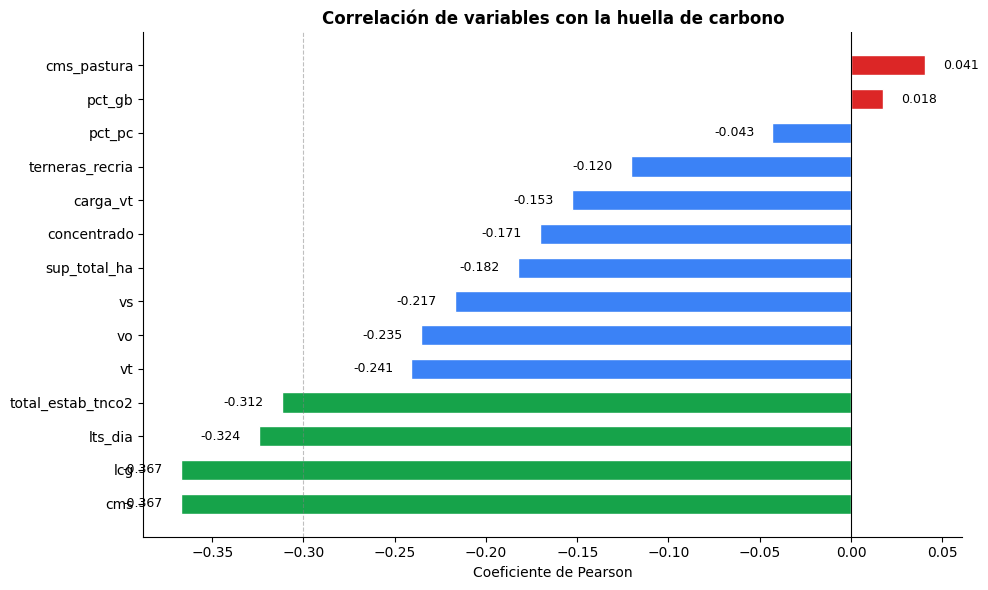

In [ ]:
features_num = [
    "sup_total_ha", "vo", "vs", "vt", "carga_vt", "concentrado",
    "cms", "cms_pastura", "lts_dia", "pct_gb", "pct_pc",
    "lcg", "terneras_recria", "total_estab_tnco2"
]

corr = (df[features_num + ["huella_kgco2_lt"]]
        .corr()["huella_kgco2_lt"]
        .drop("huella_kgco2_lt")
        .sort_values())

fig, ax = plt.subplots(figsize=(10, 6))
colores = ["#16a34a" if v < -0.3 else "#dc2626" if v > 0 else "#3b82f6"
           for v in corr.values]
bars = ax.barh(corr.index, corr.values, color=colores, edgecolor="white", height=0.6)
ax.axvline(0, color="black", linewidth=0.8)
ax.axvline(-0.3, color="gray", linewidth=0.8, linestyle="--", alpha=0.5)
for bar, val in zip(bars, corr.values):
    ax.text(val - 0.01 if val < 0 else val + 0.01,
            bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va="center",
            ha="right" if val < 0 else "left", fontsize=9)
ax.set_title("Correlación de variables con la huella de carbono", fontweight="bold")
ax.set_xlabel("Coeficiente de Pearson")
plt.tight_layout()
plt.show()

Tambos disponibles para clustering: 116


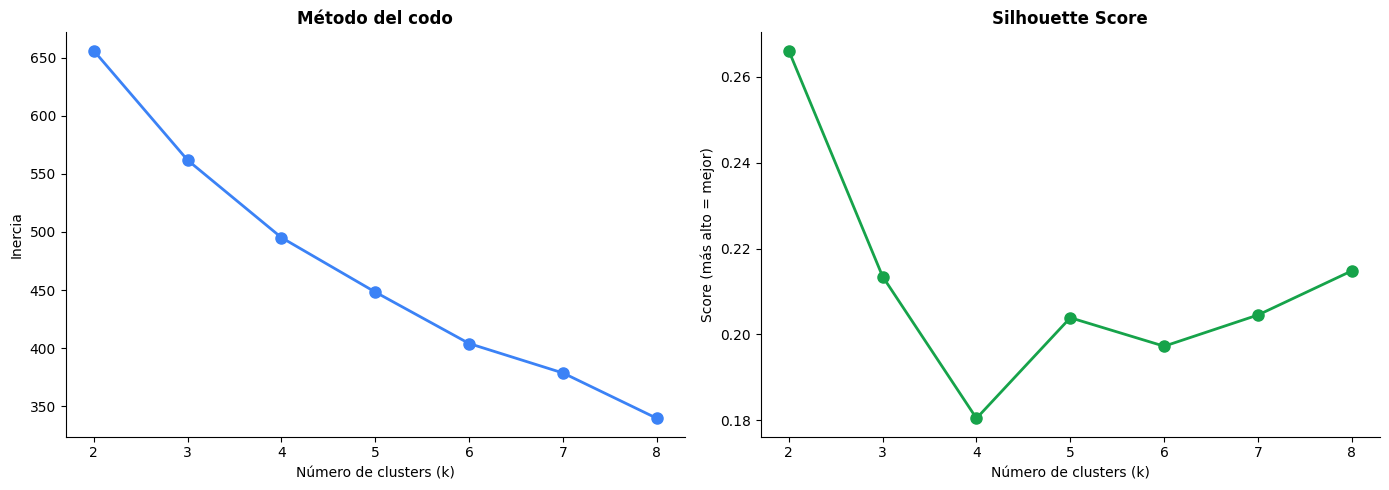


Silhouette scores:
  k=2: 0.2660
  k=3: 0.2135
  k=4: 0.1805
  k=5: 0.2039
  k=6: 0.1973
  k=7: 0.2045
  k=8: 0.2148


In [ ]:
features_cluster = [
    "sup_total_ha",
    "carga_vt",
    "vt",
    "lcg",
    "cms",
    "lts_dia",
    "total_estab_tnco2",
    "huella_kgco2_lt",
]

df_cluster = df[["id"] + features_cluster].dropna().copy()
print(f"Tambos disponibles para clustering: {len(df_cluster)}")

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster[features_cluster])

inertias    = []
silhouettes = []
rango_k     = range(2, 9)

for k in rango_k:
    km     = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(rango_k, inertias, marker="o", color="#3b82f6", linewidth=2, markersize=8)
axes[0].set_title("Método del codo", fontweight="bold")
axes[0].set_xlabel("Número de clusters (k)")
axes[0].set_ylabel("Inercia")
axes[0].set_xticks(list(rango_k))

axes[1].plot(rango_k, silhouettes, marker="o", color="#16a34a", linewidth=2, markersize=8)
axes[1].set_title("Silhouette Score", fontweight="bold")
axes[1].set_xlabel("Número de clusters (k)")
axes[1].set_ylabel("Score (más alto = mejor)")
axes[1].set_xticks(list(rango_k))

plt.tight_layout()
plt.show()

print("\nSilhouette scores:")
for k, s in zip(rango_k, silhouettes):
    print(f"  k={k}: {s:.4f}")

In [ ]:
K_OPTIMO = 3

km_final = KMeans(n_clusters=K_OPTIMO, random_state=42, n_init=10)
df_cluster["cluster"] = km_final.fit_predict(X_scaled)

print(f"Clustering con k={K_OPTIMO}:")
print(df_cluster["cluster"].value_counts().sort_index())

Clustering con k=3:
cluster
0    23
1    44
2    49
Name: count, dtype: int64


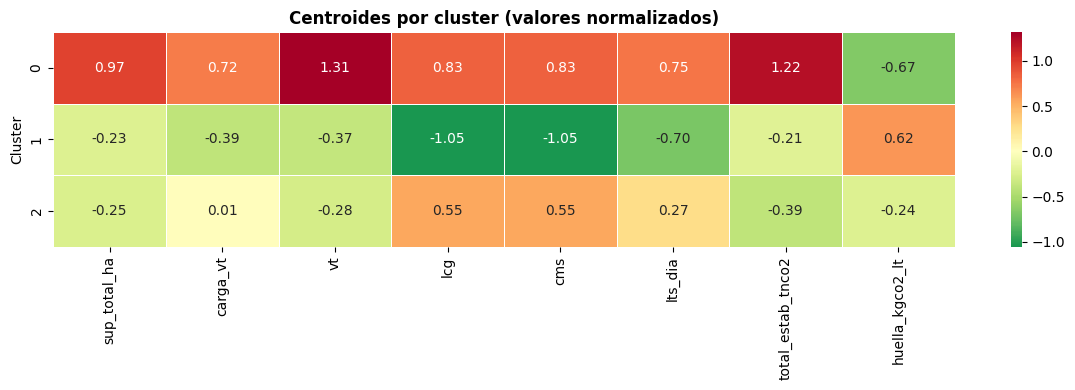

In [ ]:
centroides = pd.DataFrame(
    km_final.cluster_centers_,
    columns=features_cluster
)

fig, ax = plt.subplots(figsize=(12, 4))
sns.heatmap(centroides, annot=True, fmt=".2f", cmap="RdYlGn_r",
            center=0, linewidths=0.5, ax=ax)
ax.set_title("Centroides por cluster (valores normalizados)", fontweight="bold")
ax.set_ylabel("Cluster")
plt.tight_layout()
plt.show()

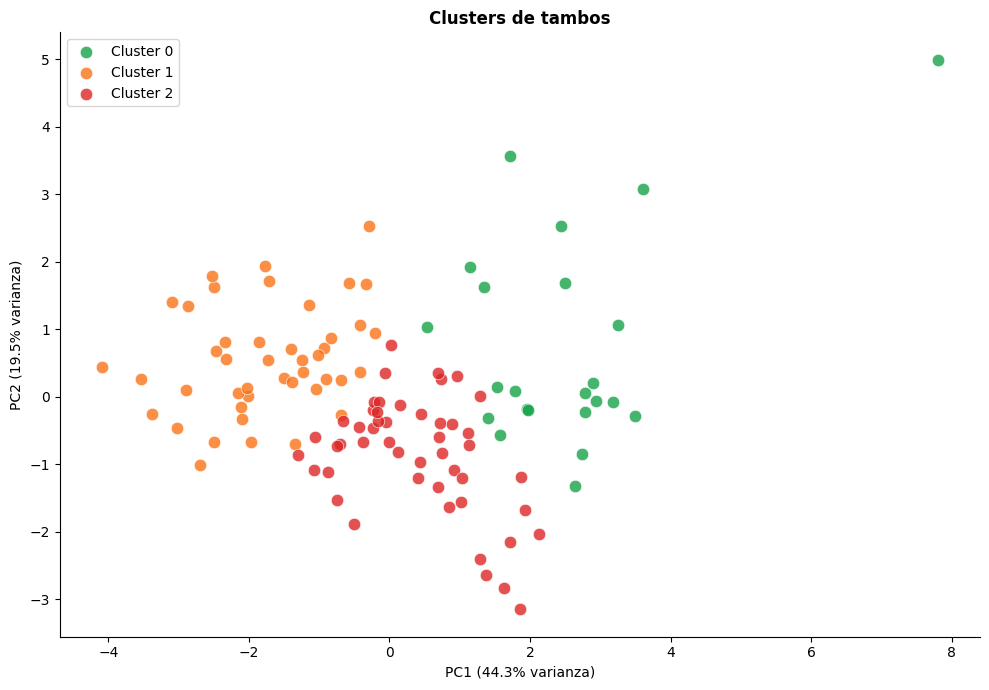


Varianza explicada PC1+PC2: 63.8%


In [ ]:
pca    = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)
df_cluster["PC1"] = coords[:, 0]
df_cluster["PC2"] = coords[:, 1]

COLORES = {0: "#16a34a", 1: "#f97316", 2: "#dc2626"}

fig, ax = plt.subplots(figsize=(10, 7))
for cl in range(K_OPTIMO):
    mask = df_cluster["cluster"] == cl
    ax.scatter(df_cluster.loc[mask, "PC1"],
               df_cluster.loc[mask, "PC2"],
               color=COLORES[cl], label=f"Cluster {cl}",
               s=80, alpha=0.8, edgecolors="white", linewidth=0.5)

ax.set_title("Clusters de tambos", fontweight="bold")
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% varianza)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% varianza)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nVarianza explicada PC1+PC2: {sum(pca.explained_variance_ratio_)*100:.1f}%")

In [ ]:
print("VALORES PROMEDIO POR CLUSTER")
print(df_cluster.groupby("cluster")[features_cluster].mean().round(3).to_string())

VALORES PROMEDIO POR CLUSTER
         sup_total_ha  carga_vt       vt     lcg     cms  lts_dia  total_estab_tnco2  huella_kgco2_lt
cluster                                                                                              
0             337.239     1.749  342.739  21.042  20.072   22.387           1334.937            0.627
1             176.705     1.196  135.159  10.342  16.136   16.035            626.057            0.888
2             173.429     1.398  145.776  19.460  19.490   20.280            535.951            0.714


In [ ]:
df_resultado = df.merge(
    df_cluster[["id", "cluster"]],
    on="id", how="inner"
)

# Ajustá estos nombres según lo que veas en la celda 12
NOMBRES_CLUSTER = {
    0: "✅ Tambos eficientes",
    1: "🔴 Tambos de Alto riesgo",
    2: "🟢 Tambos intermedios",
    }

df_resultado["perfil"] = df_resultado["cluster"].map(NOMBRES_CLUSTER)

resumen = df_resultado.groupby("perfil").agg(
    tambos             = ("id", "count"),
    huella_promedio    = ("huella_kgco2_lt", "mean"),
    huella_max         = ("huella_kgco2_lt", "max"),
    costo_promedio_eur = ("costo_ambiental_eur", "mean"),
    costo_total_eur    = ("costo_ambiental_eur", "sum"),
    lts_promedio       = ("lts_dia", "mean"),
).round(2)

print(f"REPORTE DE COSTO AMBIENTAL POR CLUSTER")
print(f"Tasa aplicada: EUR {TASA} / tn CO2eq\n")
print(resumen.to_string())

REPORTE DE COSTO AMBIENTAL POR CLUSTER
Tasa aplicada: EUR 16 / tn CO2eq

                         tambos  huella_promedio  huella_max  costo_promedio_eur  costo_total_eur  lts_promedio
perfil                                                                                                         
✅ Tambos eficientes          23             0.63        0.84            21358.99        491256.80         22.39
🔴 Tambos de Alto riesgo      44             0.89        1.55            10016.92        440744.32         16.03
🟢 Tambos intermedios         49             0.71        1.13             8575.22        420185.76         20.28


In [ ]:
print(df_resultado[df_resultado["id"] == 81][
    ["id", "cuenca", "sistema", "perfil",
     "sup_total_ha", "vt", "carga_vt",
     "lts_dia", "cms", "lcg",
     "total_estab_tnco2", "huella_kgco2_lt",
     "costo_ambiental_eur"]
].to_string())

    id       cuenca sistema                   perfil  sup_total_ha  vt  carga_vt  lts_dia    cms    lcg  total_estab_tnco2  huella_kgco2_lt  costo_ambiental_eur
80  81  SUR CORDOBA     PMR  🔴 Tambos de Alto riesgo         120.0  79      0.86     18.7  19.17  18.59            2569.81             1.55             41116.96
